In [1]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("urbikn/sroie-datasetv2")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.
Path to dataset files: /kaggle/input/sroie-datasetv2


In [2]:
#cek isi folder
import os

os.listdir(path)

['SROIE2019']

In [3]:
os.listdir(f"{path}/SROIE2019")

['layoutlm-base-uncased', 'test', 'train']

In [4]:
train_dir = f"{path}/SROIE2019/train"

os.listdir(train_dir)

['box', 'entities', 'img']

In [5]:
train_img_dir = os.path.join(train_dir, "img")

In [6]:
!pip install easyocr

In [7]:
import easyocr
import cv2
import matplotlib.pyplot as plt

In [8]:
# Initialize OCR
reader = easyocr.Reader(['en'])

In [9]:
# ambil 1 gambar
import os

image_path = os.path.join(
    train_img_dir,
    os.listdir(train_img_dir)[0]
)

print(image_path)

/kaggle/input/sroie-datasetv2/SROIE2019/train/img/X51007231344.jpg


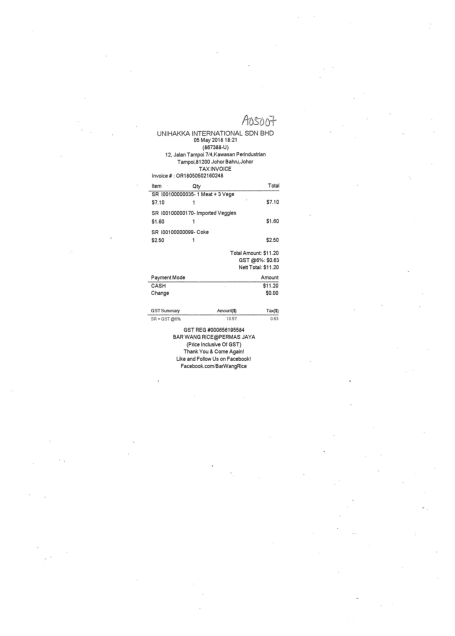

In [10]:
#tampilkan gambar
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [11]:
results = reader.readtext(image_path)

results[:5]

[([[np.int32(2617), np.int32(1176)],
   [np.int32(3060), np.int32(1176)],
   [np.int32(3060), np.int32(1357)],
   [np.int32(2617), np.int32(1357)]],
  'Ansdot',
  np.float64(0.23436819839431744)),
 ([[np.int32(1667), np.int32(1357)],
   [np.int32(3017), np.int32(1357)],
   [np.int32(3017), np.int32(1460)],
   [np.int32(1667), np.int32(1460)]],
  'UNIHAKKA INTERNATIONAL SDN BHD',
  np.float64(0.8124257636537321)),
 ([[np.int32(2083), np.int32(1447)],
   [np.int32(2164), np.int32(1447)],
   [np.int32(2164), np.int32(1512)],
   [np.int32(2083), np.int32(1512)]],
  '05',
  np.float64(0.9999713402633025)),
 ([[np.int32(2290), np.int32(1441)],
   [np.int32(2593), np.int32(1441)],
   [np.int32(2593), np.int32(1513)],
   [np.int32(2290), np.int32(1513)]],
  '2018 18.21',
  np.float64(0.9883537177263266)),
 ([[np.int32(2174), np.int32(1522)],
   [np.int32(2506), np.int32(1522)],
   [np.int32(2506), np.int32(1613)],
   [np.int32(2174), np.int32(1613)]],
  '(867388-U)',
  np.float64(0.99795551673

In [12]:
texts = [item[1] for item in results]

print(texts)

['Ansdot', 'UNIHAKKA INTERNATIONAL SDN BHD', '05', '2018 18.21', '(867388-U)', '12, Jalan Tampoi 7/4,Kawasan Perindustrian', 'Tampoi,81200 Johor Bahru,Johor', 'TAXINVOICE', 'Invoice #', 'OR18050502160248', 'Item', 'Total', 'SR 100100000035-', 'Meat + 3', 'S7.10', 'S7.10', 'SR I00100000170- Imported Veggies', '$1.60', 'S1.60', 'SR 100100000099- Coke', 'S2.50', 'S2.50', 'Total Amount: S11.20', 'GST @69: $0.63', 'Nett Total: $11.20', 'Payment Mode', 'Amount', 'CASH', 'S11.20', 'Change', 'S0.00', 'GST Summary', 'Amount(s)', 'Taxys)', 'SR = GST @6%', '10.57', '63', 'GST REG #000656195584', 'BAR WANG RICE@PERMAS JAYA', '(Price Inclusive Of GST)', 'Thank You & Come Againl', 'Like and Follow Us on Facebookl', 'Facebook com/BarWangRice', 'May', 'aty', 'Vege']


In [13]:
full_text = " ".join(texts)

print(full_text)

Ansdot UNIHAKKA INTERNATIONAL SDN BHD 05 2018 18.21 (867388-U) 12, Jalan Tampoi 7/4,Kawasan Perindustrian Tampoi,81200 Johor Bahru,Johor TAXINVOICE Invoice # OR18050502160248 Item Total SR 100100000035- Meat + 3 S7.10 S7.10 SR I00100000170- Imported Veggies $1.60 S1.60 SR 100100000099- Coke S2.50 S2.50 Total Amount: S11.20 GST @69: $0.63 Nett Total: $11.20 Payment Mode Amount CASH S11.20 Change S0.00 GST Summary Amount(s) Taxys) SR = GST @6% 10.57 63 GST REG #000656195584 BAR WANG RICE@PERMAS JAYA (Price Inclusive Of GST) Thank You & Come Againl Like and Follow Us on Facebookl Facebook com/BarWangRice May aty Vege


**preprocessing**

In [14]:
import re

# lowercase
clean_text = full_text.lower()

# hapus karakter aneh
clean_text = re.sub(
    r'[^a-zA-Z0-9\s\.\,\/\-]',
    ' ',
    clean_text
)

# hapus spasi berlebih
clean_text = re.sub(r'\s+', ' ', clean_text)

print(clean_text)

ansdot unihakka international sdn bhd 05 2018 18.21 867388-u 12, jalan tampoi 7/4,kawasan perindustrian tampoi,81200 johor bahru,johor taxinvoice invoice or18050502160248 item total sr 100100000035- meat 3 s7.10 s7.10 sr i00100000170- imported veggies 1.60 s1.60 sr 100100000099- coke s2.50 s2.50 total amount s11.20 gst 69 0.63 nett total 11.20 payment mode amount cash s11.20 change s0.00 gst summary amount s taxys sr gst 6 10.57 63 gst reg 000656195584 bar wang rice permas jaya price inclusive of gst thank you come againl like and follow us on facebookl facebook com/barwangrice may aty vege


In [15]:
date_pattern = r'\d{2}/\d{2}/\d{4}'

dates = re.findall(date_pattern, clean_text)

print(dates)

[]


In [16]:
# ekstrak nominal
amount_pattern = r'\d+\.\d{2}'

amounts = re.findall(amount_pattern, clean_text)

print(amounts[:10])

['18.21', '7.10', '7.10', '1.60', '1.60', '2.50', '2.50', '11.20', '0.63', '11.20']


In [17]:
# cari total pembayaran
total_pattern = r'nett total\s(\d+\.\d{2})'

total_match = re.findall(
    total_pattern,
    clean_text
)

total_amount = (
    float(total_match[0])
    if total_match
    else None
)

print(total_amount)

11.2


In [18]:
import pandas as pd

data = {
    'date': dates[0] if dates else None,
    'total_amount': total_amount,
    'raw_text': clean_text
}

df = pd.DataFrame([data])

print(df.head())

   date  total_amount                                           raw_text
0  None          11.2  ansdot unihakka international sdn bhd 05 2018 ...


In [19]:
clean_text = clean_text.strip()

In [20]:
df.to_csv('financial_transactions.csv', index=False)

print("CSV berhasil disimpan")

CSV berhasil disimpan


In [21]:
pd.read_csv("financial_transactions.csv")

,date,total_amount,raw_text
0,NaN,11.2,ansdot unihakka international sdn bhd 05 2018 ...


**semua data**

In [22]:
all_data = []

# ambil 50 gambar
image_files = os.listdir(train_img_dir)[:50]

for image_name in image_files:

    print(f"Processing: {image_name}")

    try:

        # path gambar
        image_path = os.path.join(
            train_img_dir,
            image_name
        )

        # OCR
        results = reader.readtext(image_path)

        # ambil text saja
        texts = [item[1] for item in results]

        # gabung text
        full_text = " ".join(texts)

        # preprocessing
        clean_text = full_text.lower()

        clean_text = re.sub(
            r'[^a-zA-Z0-9\s\.\,\/\-]',
            ' ',
            clean_text
        )

        clean_text = re.sub(
            r'\s+',
            ' ',
            clean_text
        )

        clean_text = clean_text.strip()

        # extract tanggal
        date_patterns = [
            r'\d{2}/\d{2}/\d{4}',
            r'\d{2}-\d{2}-\d{4}',
            r'\d{4}/\d{2}/\d{2}',
            r'\d{2}\.\d{2}\.\d{4}',
            r'\d{2}\s\d{2}\s\d{4}'
            ]

        dates = []

        # cari tanggal dari semua pola
        for pattern in date_patterns:
          found_dates = re.findall(
              pattern,
              clean_text
              )

          if found_dates:
            dates.extend(found_dates)

            print(dates)

        # extract total transaksi
        amount_pattern = r'\d+\.\d{2}'
        amounts = re.findall(
            amount_pattern,
            clean_text
            )

        amounts_float = [
            float(x)
            for x in amounts
            ]

        # ambil nominal terbesar
        total_amount = (
            max(amounts_float)
            if amounts_float
            else None
            )

        # kurs dollar ke rupiah
        exchange_rate = 16500

        # konversi ke rupiah
        total_amount_rupiah = (
            int(total_amount * exchange_rate)
            if total_amount
            else None
            )

        # simpan data
        data = {
           'image_name': image_name,
           'date': dates[0] if dates else None,
           'total_amount_dollar': total_amount,
           'total_amount_rupiah': total_amount_rupiah,
           'raw_text': clean_text
           }

        all_data.append(data)

    except Exception as e:
        print(f"Error pada {image_name}: {e}")

Processing: X51007231344.jpg
Processing: X51005442344.jpg
['13/03/2018']
Processing: X51008142030.jpg
['05-06-2018', '05-06-2018']
Processing: X51005447853.jpg
Processing: X51007339113.jpg
['24/07/2017']
Processing: X51005453729.jpg
Processing: X51005763940.jpg
['00-88-5200']
['00-88-5200', '14 08 2007']
Processing: X51005711442.jpg
['16-03-2018']
Processing: X51006389888.jpg
Processing: X51007419197.jpg
['28/06/2018']
['28/06/2018', '00 88 1231']
Processing: X51008123604.jpg
['24/06/2018']
Processing: X51006556815.jpg
['05/09/2017']
Processing: X51005441408.jpg
['10-03-2018', '11-03-2018']
Processing: X51006620189.jpg
['14 65 9547']
Processing: X51008114283.jpg
['26 12 9555']
Processing: X51006311764.jpg
['29/03/2018']
['29/03/2018', '29-03-2018']
Processing: X51008099044.jpg
Processing: X51005361897.jpg
['17/01/2018']
Processing: X51007103639.jpg
Processing: X51006414392.jpg
['07/04/2018', '07/04/2018']
Processing: X51006414394.jpg
['27/04/2018']
Processing: X51008164997.jpg
['15-06-

In [23]:
df = pd.DataFrame(all_data)

# handling missing value
df["date"] = df["date"].fillna("unknown")

df["total_amount_dollar"] = (
    df["total_amount_dollar"]
    .fillna(0)
)

df["total_amount_rupiah"] = (
    df["total_amount_rupiah"]
    .fillna(0)
    .astype(int)
)

df.head()

,image_name,date,total_amount_dollar,total_amount_rupiah,raw_text
0,X51007231344.jpg,unknown,18.21,300465,ansdot unihakka international sdn bhd 05 2018 ...
1,X51005442344.jpg,13/03/2018,700.88,11564520,yozo 2 yong tat hardware trading jm0292437-d n...
2,X51008142030.jpg,05-06-2018,0.00,0,cne one three seafood restaurant sdn bhd 11209...
3,X51005447853.jpg,unknown,150.08,2476320,"39 steed mart s/d 519537.x lot p,t. 2811, jala..."
4,X51007339113.jpg,24/07/2017,6.00,99000,"sanyu stationery shop no. 3168336, jalan setia..."


In [24]:
#cek missing value
df.isnull().sum()

,0
image_name,0
date,0
total_amount_dollar,0
total_amount_rupiah,0
raw_text,0


In [25]:
df.head()

,image_name,date,total_amount_dollar,total_amount_rupiah,raw_text
0,X51007231344.jpg,unknown,18.21,300465,ansdot unihakka international sdn bhd 05 2018 ...
1,X51005442344.jpg,13/03/2018,700.88,11564520,yozo 2 yong tat hardware trading jm0292437-d n...
2,X51008142030.jpg,05-06-2018,0.00,0,cne one three seafood restaurant sdn bhd 11209...
3,X51005447853.jpg,unknown,150.08,2476320,"39 steed mart s/d 519537.x lot p,t. 2811, jala..."
4,X51007339113.jpg,24/07/2017,6.00,99000,"sanyu stationery shop no. 3168336, jalan setia..."


In [26]:
df.shape

(50, 5)

In [27]:
df.to_csv(
    'ocr_bersih.csv',
    index=False
)

print("CSV berhasil disimpan")

CSV berhasil disimpan


In [28]:
print("EDA Dollar")
print(df['total_amount_dollar'].describe())

print("\nEDA Rupiah")
print(df['total_amount_rupiah'].describe())

EDA Dollar
count      50.00000
mean      230.53160
std       786.22746
min         0.00000
25%        23.58500
50%        50.30000
75%       168.69500
max      5542.82000
Name: total_amount_dollar, dtype: float64

EDA Rupiah
count    5.000000e+01
mean     3.803771e+06
std      1.297275e+07
min      0.000000e+00
25%      3.891525e+05
50%      8.299500e+05
75%      2.783468e+06
max      9.145653e+07
Name: total_amount_rupiah, dtype: float64


Histogram Dollar


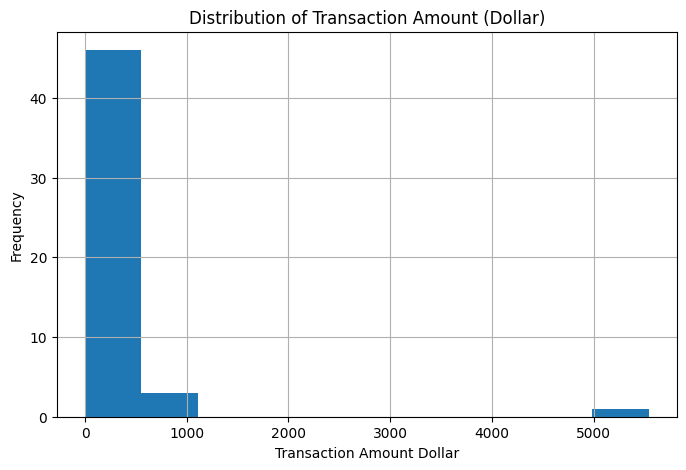

Histogram Rupiah


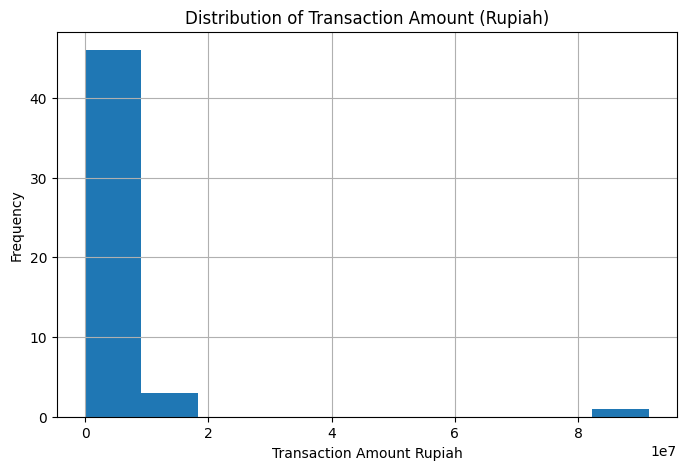

In [29]:
print("Histogram Dollar")

plt.figure(figsize=(8,5))

df['total_amount_dollar'].hist()

plt.title('Distribution of Transaction Amount (Dollar)')

plt.xlabel('Transaction Amount Dollar')

plt.ylabel('Frequency')

plt.show()


print("Histogram Rupiah")

plt.figure(figsize=(8,5))

df['total_amount_rupiah'].hist()

plt.title('Distribution of Transaction Amount (Rupiah)')

plt.xlabel('Transaction Amount Rupiah')

plt.ylabel('Frequency')

plt.show()

| Column       | Data Type | Description                     |
| ------------ | --------- | ------------------------------- |
| image_name   | string    | nama file gambar receipt        |
| date         | datetime  | tanggal transaksi hasil OCR     |
| total_amount | float     | total nominal transaksi         |
| raw_text     | text      | hasil OCR setelah preprocessing |
